In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/rahulinchal/SPPU/refs/heads/main/Data/data_email_campaign.csv")
df.head()

,Email_ID,Email_Type,Subject_Hotness_Score,Email_Source_Type,Customer_Location,Email_Campaign_Type,Total_Past_Communications,Time_Email_sent_Category,Word_Count,Total_Links,Total_Images,Email_Status
0,EMA00081000034500,1,2.2,2,E,2,33.0,1,440,8.0,0.0,0
1,EMA00081000045360,2,2.1,1,NaN,2,15.0,2,504,5.0,0.0,0
2,EMA00081000066290,2,0.1,1,B,3,36.0,2,962,5.0,0.0,1
3,EMA00081000076560,1,3.0,2,E,2,25.0,2,610,16.0,0.0,0
4,EMA00081000109720,1,0.0,2,C,3,18.0,2,947,4.0,0.0,0


In [3]:
df.columns

Index(['Email_ID', 'Email_Type', 'Subject_Hotness_Score', 'Email_Source_Type',
       'Customer_Location', 'Email_Campaign_Type', 'Total_Past_Communications',
       'Time_Email_sent_Category', 'Word_Count', 'Total_Links', 'Total_Images',
       'Email_Status'],
      dtype='object')

In [4]:
df.shape

(68353, 12)

In [5]:
df.isnull().sum()

Email_ID                         0
Email_Type                       0
Subject_Hotness_Score            0
Email_Source_Type                0
Customer_Location            11595
Email_Campaign_Type              0
Total_Past_Communications     6825
Time_Email_sent_Category         0
Word_Count                       0
Total_Links                   2201
Total_Images                  1677
Email_Status                     0
dtype: int64

In [6]:
df["Customer_Location"].fillna(df["Customer_Location"].mode()[0], inplace=True)

In [7]:
df["Total_Past_Communications"].fillna(int(df["Total_Past_Communications"].mean()),inplace=True)

In [8]:
df["Total_Links"].fillna(int(df["Total_Links"].mean()),inplace=True)

In [9]:
df["Total_Images"].fillna(int(df["Total_Images"].mean()),inplace=True)

In [10]:
df.isnull().sum()

Email_ID                     0
Email_Type                   0
Subject_Hotness_Score        0
Email_Source_Type            0
Customer_Location            0
Email_Campaign_Type          0
Total_Past_Communications    0
Time_Email_sent_Category     0
Word_Count                   0
Total_Links                  0
Total_Images                 0
Email_Status                 0
dtype: int64

In [11]:
df.dtypes  

Email_ID                      object
Email_Type                     int64
Subject_Hotness_Score        float64
Email_Source_Type              int64
Customer_Location             object
Email_Campaign_Type            int64
Total_Past_Communications    float64
Time_Email_sent_Category       int64
Word_Count                     int64
Total_Links                  float64
Total_Images                 float64
Email_Status                   int64
dtype: object

In [12]:
df['Total_Past_Communications'] = df['Total_Past_Communications'].astype(int)
df['Total_Links'] = df['Total_Links'].astype(int)
df['Total_Images'] = df['Total_Images'].astype(int)

In [13]:
df.dtypes

Email_ID                      object
Email_Type                     int64
Subject_Hotness_Score        float64
Email_Source_Type              int64
Customer_Location             object
Email_Campaign_Type            int64
Total_Past_Communications      int32
Time_Email_sent_Category       int64
Word_Count                     int64
Total_Links                    int32
Total_Images                   int32
Email_Status                   int64
dtype: object

In [14]:
for i in df.columns:
    print(i,"\n",df[i].unique(),"\n")

Email_ID 
 ['EMA00081000034500' 'EMA00081000045360' 'EMA00081000066290' ...
 'EMA00089998436500' 'EMA00089999168800' 'EMA00089999316900'] 

Email_Type 
 [1 2] 

Subject_Hotness_Score 
 [2.2 2.1 0.1 3.  0.  1.5 3.2 0.7 2.  0.5 0.2 1.  4.  1.9 1.1 1.6 0.3 2.3
 1.4 1.7 2.8 1.2 0.8 0.6 4.2 1.8 2.4 0.9 1.3 3.3 2.6 3.1 4.1 2.9 2.7 0.4
 3.5 3.7 2.5 3.8 3.9 3.4 4.6 4.5 3.6 4.4 4.7 5.  4.3 4.8 4.9] 

Email_Source_Type 
 [2 1] 

Customer_Location 
 ['E' 'G' 'B' 'C' 'D' 'F' 'A'] 

Email_Campaign_Type 
 [2 3 1] 

Total_Past_Communications 
 [33 15 36 25 18 28 34 21 40 27 24 42 11 23 37 35 51  9 39 31 50 30 14 45
 53  7 38 52 22 43 12 16 20 41 56 26 29  5 32 44 10 17 46 47 48  8 49 13
  0  6 55 19 60 59 61 54 62 57 64 58 65 66 67 63] 

Time_Email_sent_Category 
 [1 2 3] 

Word_Count 
 [ 440  504  962  610  947  416  116 1241  655  744  931  550  565  700
  694 1061  623  560 1082  684  733 1122  649  778  855  704  339  988
  389  636  812  880  254  490  771  353  484  922  275  392  520  458
  63

In [15]:
df.duplicated().sum()

0

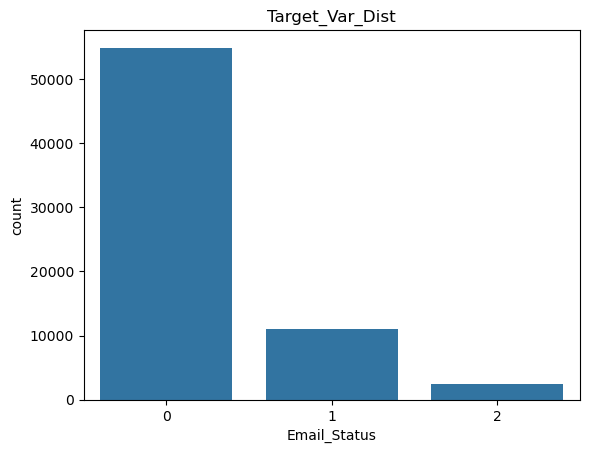

In [16]:
sns.countplot(x='Email_Status', data=df)
plt.title("Target_Var_Dist")
plt.show()

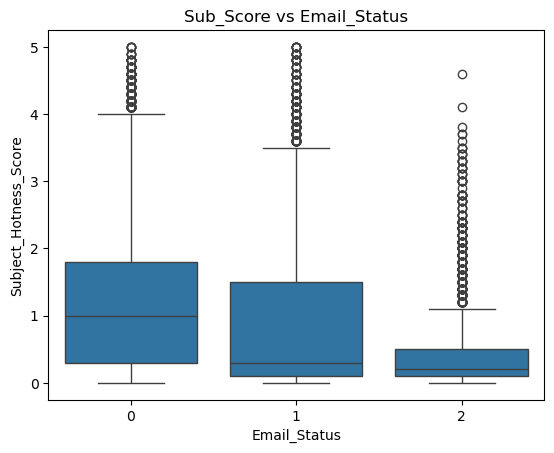

In [17]:
sns.boxplot(x='Email_Status', y='Subject_Hotness_Score', data=df)
plt.title("Sub_Score vs Email_Status")
plt.show()

In [18]:
# df.columns = df.columns.str.strip()
# selected_cols = ['Subject_Hotness_Score', 'Word_Count', 'Total_Links', 'Total_Images', 'Email_Status']
# plot_df = df[selected_cols].dropna()
# plot_df['Email_Status'] = plot_df['Email_Status'].astype(str)
# sns.pairplot(plot_df, hue='Email_Status')
# plt.show()

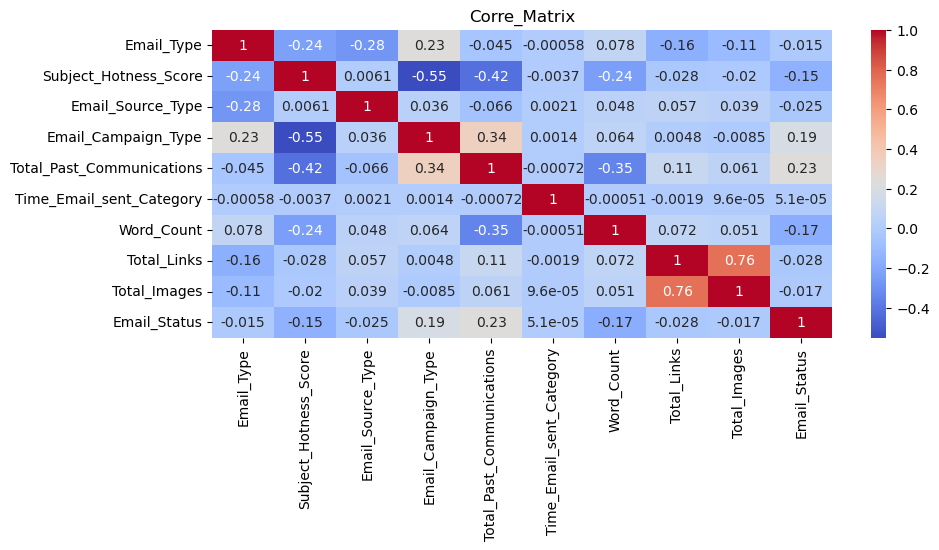

In [19]:
plt.figure(figsize=(10,4))
numeric_df = df.select_dtypes(include=[np.number]) 
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Corre_Matrix")
plt.show()

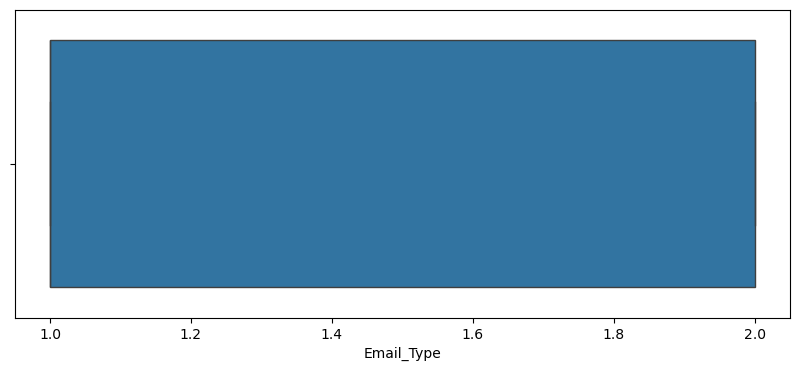

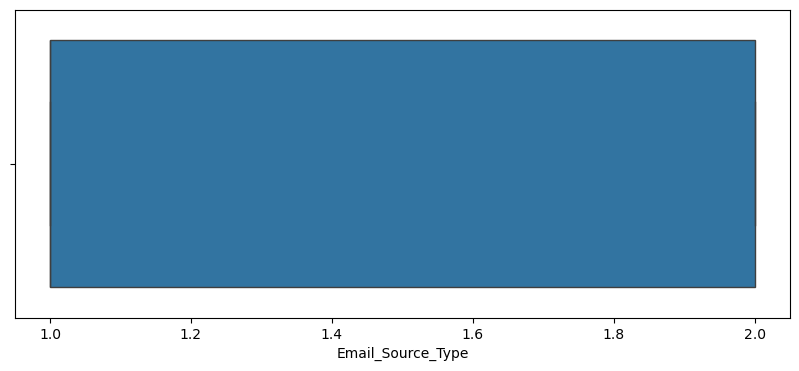

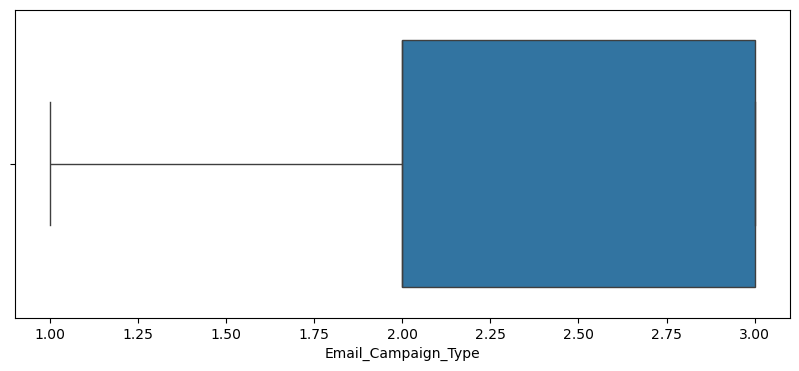

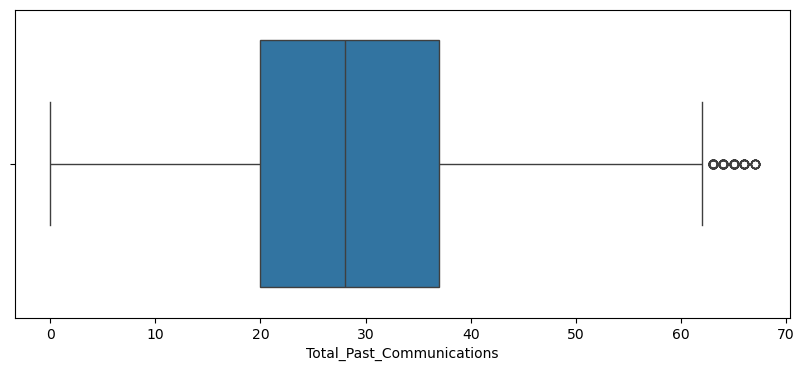

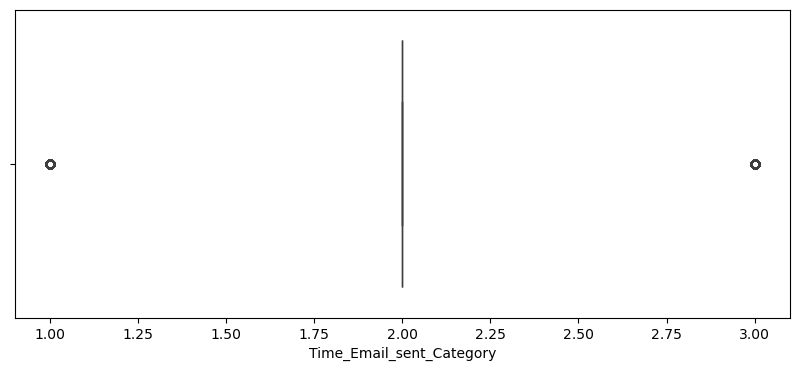

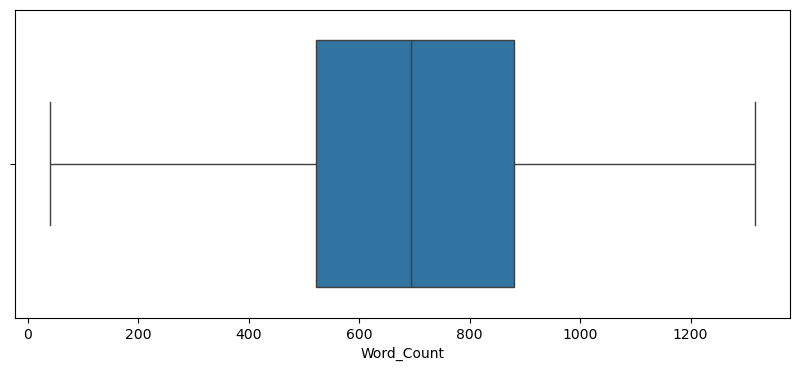

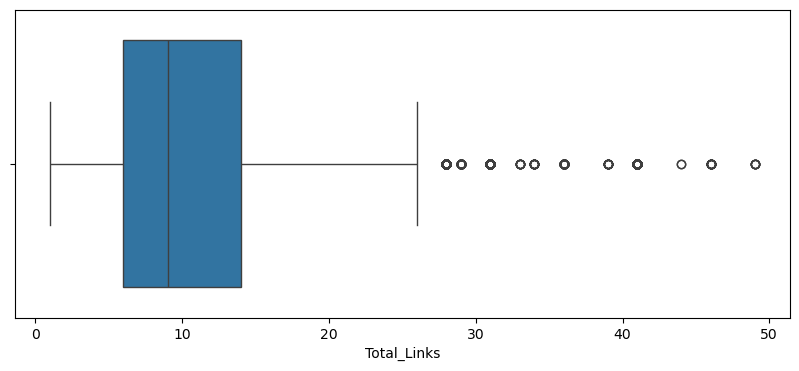

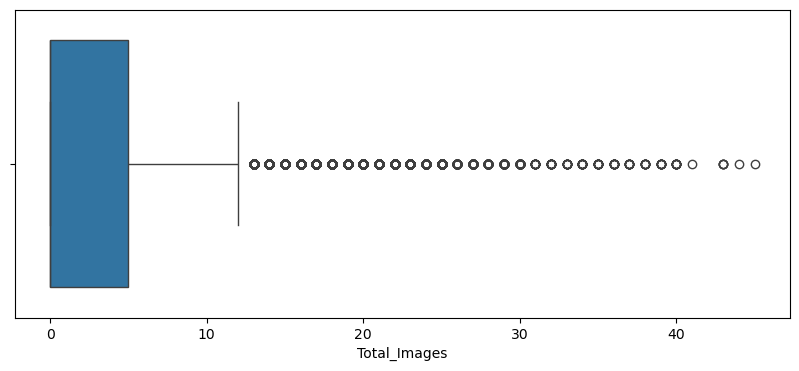

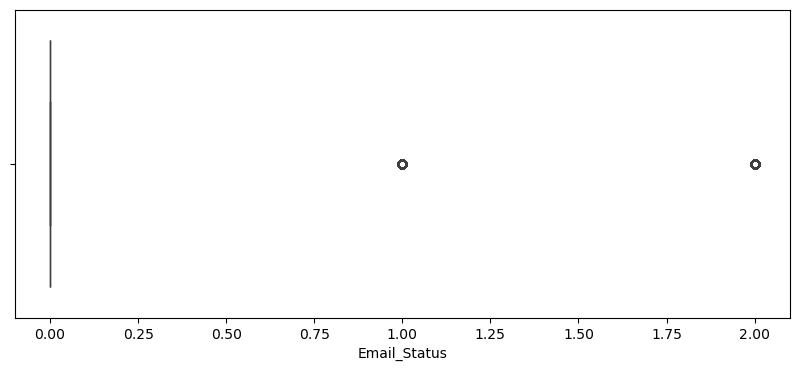

In [20]:
int_columns = df.select_dtypes(include = 'int')
for i in int_columns.columns:
    plt.figure(figsize = (10,4))
    sns.boxplot(x = int_columns[i])
    plt.show()

In [21]:
df.shape

(68353, 12)

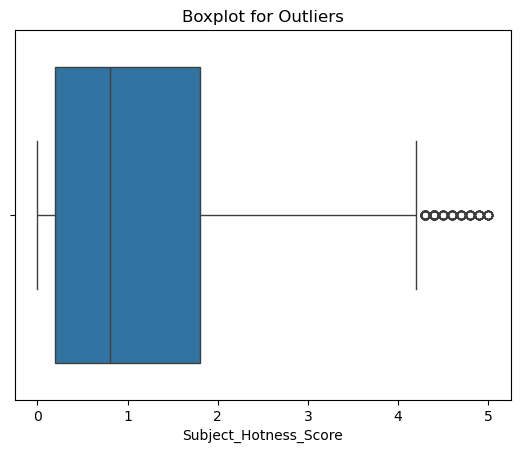

In [22]:
sns.boxplot(x=df['Subject_Hotness_Score'])
plt.title("Boxplot for Outliers")
plt.show()

In [23]:
df = df[df['Total_Links'] < 30]

In [24]:
df = df[df['Total_Images'] < 20]

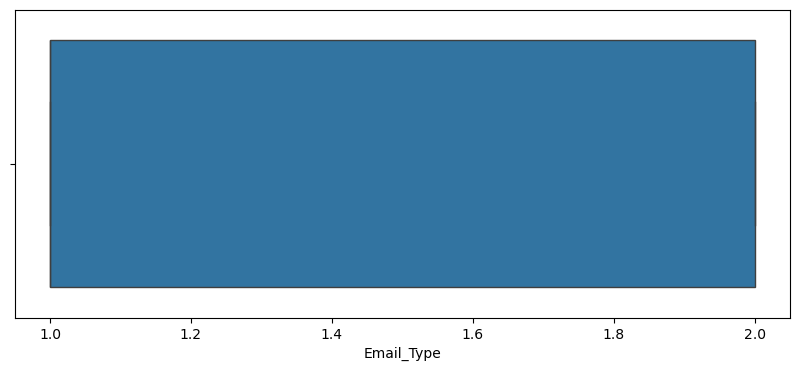

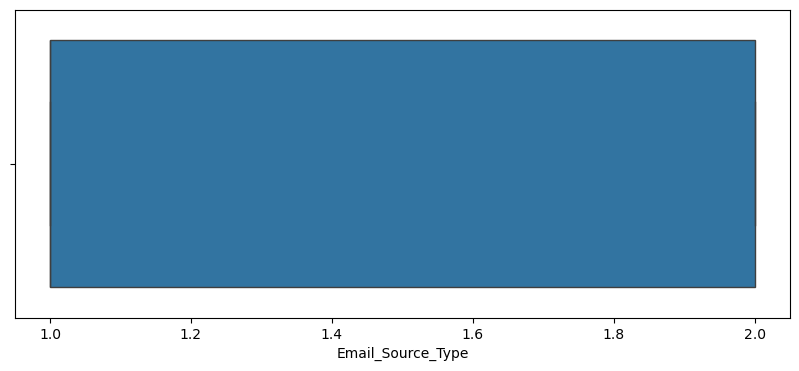

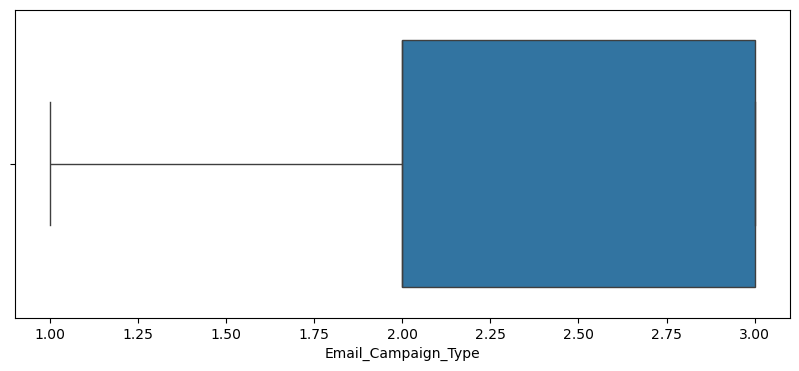

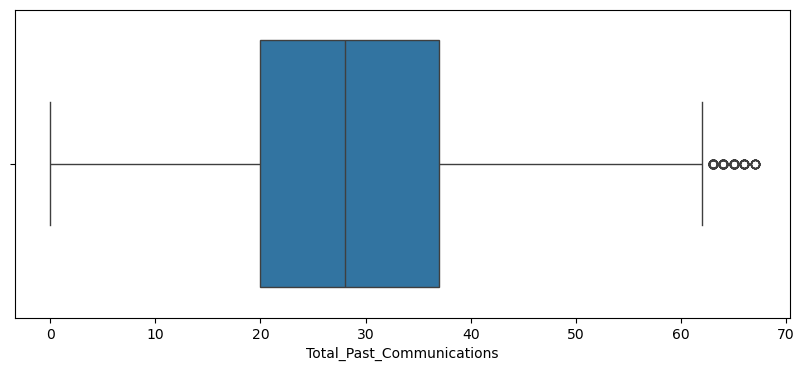

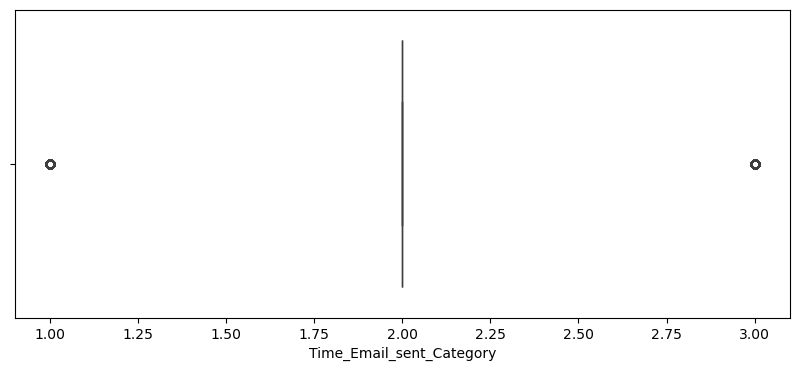

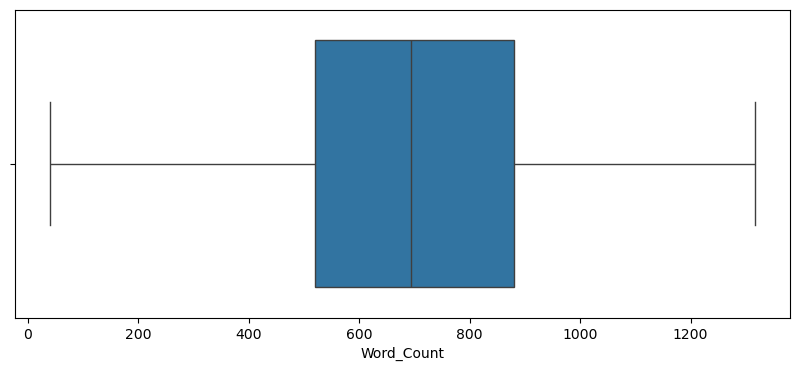

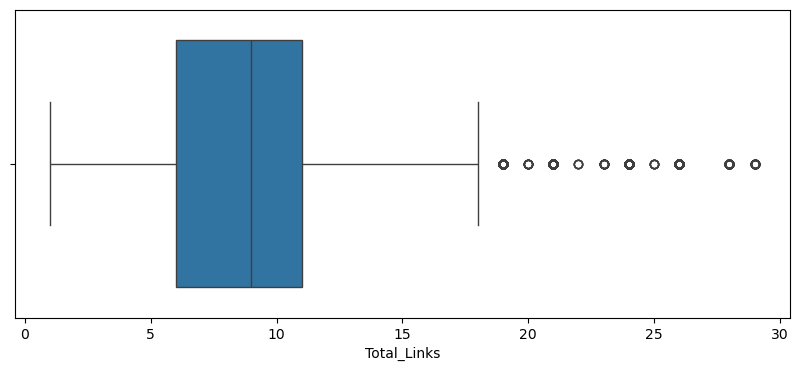

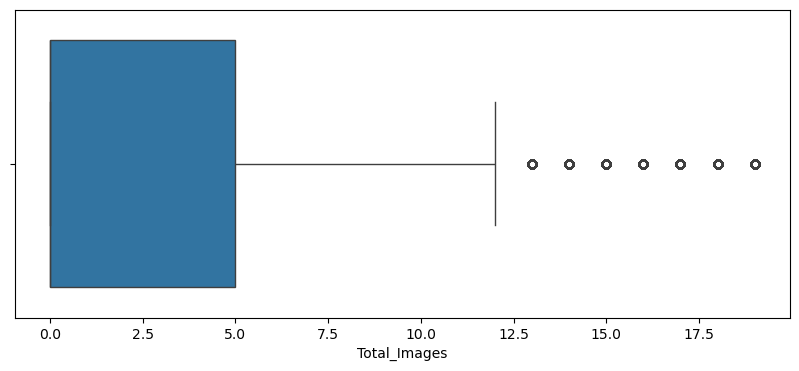

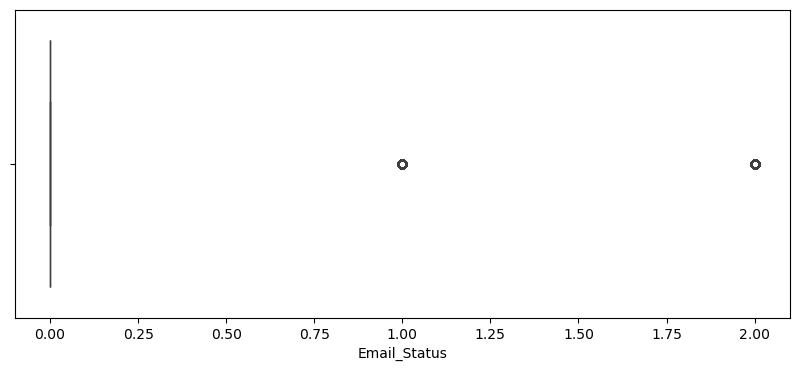

In [25]:
int_columns = df.select_dtypes(include = 'int')
for i in int_columns.columns:
    plt.figure(figsize = (10,4))
    sns.boxplot(x = int_columns[i])
    plt.show()

In [26]:
df.shape

(66227, 12)

Skewness before: 0.016455695570825015


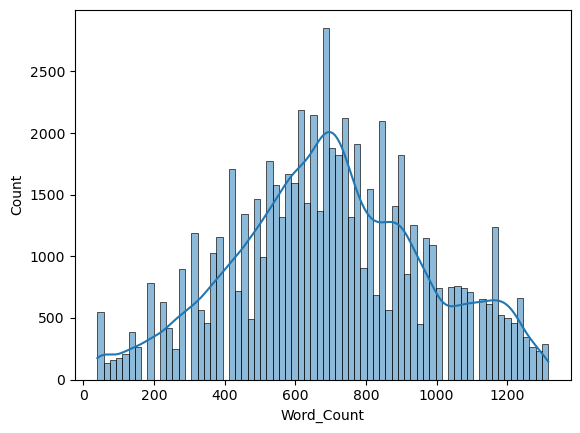

Skewness after: -1.9451380572275208


In [27]:
from scipy.stats import skew

print("Skewness before:", skew(df['Word_Count']))
sns.histplot(df['Word_Count'], kde=True)
plt.show()
df['Word_Count'] = np.log1p(df['Word_Count'])
print("Skewness after:", skew(df['Word_Count']))

In [28]:
df['LinksPerWord'] = df['Total_Links'] / (df['Word_Count'] + 1)

In [29]:
df.sample(1)

,Email_ID,Email_Type,Subject_Hotness_Score,Email_Source_Type,Customer_Location,Email_Campaign_Type,Total_Past_Communications,Time_Email_sent_Category,Word_Count,Total_Links,Total_Images,Email_Status,LinksPerWord
59854,EMA00086358708670,1,1.8,2,F,2,35,3,5.743003,16,2,0,2.37283


In [30]:
df = pd.get_dummies(df, columns=['Email_Type', 'Email_Source_Type', 'Email_Campaign_Type','Customer_Location', 'Time_Email_sent_Category'], drop_first=True)

In [31]:
df.sample(5)

,Email_ID,Subject_Hotness_Score,Total_Past_Communications,Word_Count,Total_Links,Total_Images,Email_Status,LinksPerWord,Email_Type_2,Email_Source_Type_2,Email_Campaign_Type_2,Email_Campaign_Type_3,Customer_Location_B,Customer_Location_C,Customer_Location_D,Customer_Location_E,Customer_Location_F,Customer_Location_G,Time_Email_sent_Category_2,Time_Email_sent_Category_3
65737,EMA00087678757600,2.7,28,6.483107,21,19,0,2.806321,False,False,True,False,False,False,False,True,False,False,False,False
42372,EMA00084786450920,0.1,48,5.905362,4,0,0,0.579260,False,True,False,True,False,False,False,False,False,True,True,False
47230,EMA00085224715270,1.7,28,6.805723,2,0,0,0.256222,False,True,True,False,False,False,False,True,False,False,True,False
39360,EMA00084523584530,0.5,28,7.054450,21,8,0,2.607254,False,False,True,False,False,False,False,False,False,True,True,False
35894,EMA00084215744560,0.1,30,6.196444,5,0,0,0.694788,True,False,False,True,False,False,True,False,False,False,True,False


In [32]:
df.shape

(66227, 20)

In [33]:
X = df.drop(['Email_Status', 'Email_ID'], axis=1)
y = df['Email_Status']

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, shuffle=True, test_size=0.2,random_state=1)

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X_train,y_train) # Fitting the model

LogisticRegression()

In [37]:
y_pred = log_reg.predict(X_test)
print(y_pred)

[0 0 0 ... 1 0 0]


In [38]:
print("Trainig Score: ",(log_reg.score(X_train, y_train))*100,"%")
print("Testing Score: ",(log_reg.score(X_test, y_test))*100,"%")

Trainig Score:  80.70817840357864 %
Testing Score:  81.48875132115356 %


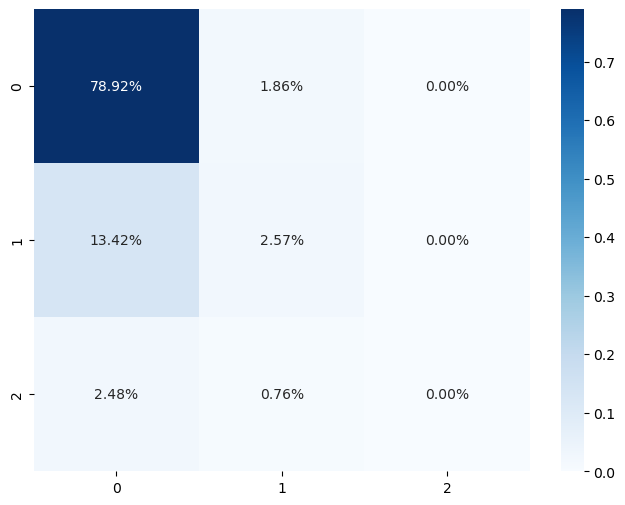

Accuracy: 81.48875132115356
Precision: 0.44243216655909096
Recall: 0.3792046583288819
F1 Score: 0.38047718228175736
Confusion Matrix:
 [[10454   246     0]
 [ 1777   340     0]
 [  328   101     0]]


In [39]:
def evaluate_model(model, X_test, y_test):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

    # Predict Test Data 
    y_pred = model.predict(X_test)

    # Calculate accuracy, precision, recall and f1-score
    acc = accuracy_score(y_test, y_pred) * 100  # accuracy has no average
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    # Display Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Visualization of Confusion matrix
    plt.figure(figsize=(8,6))
    sns.heatmap(cm/np.sum(cm), annot=True, fmt='.2%', cmap='Blues')
    plt.show()

    return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'cm': cm}
# Evaluate Model
logreg_score = evaluate_model(log_reg, X_test, y_test)

# Print result
print('Accuracy:', logreg_score['acc'])
print('Precision:', logreg_score['prec'])
print('Recall:', logreg_score['rec'])
print('F1 Score:', logreg_score['f1'])
print('Confusion Matrix:\n', logreg_score['cm'])

In [40]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()
dtree.fit(X_train,y_train)

DecisionTreeClassifier()

In [41]:
y_pred = dtree.predict(X_test)

In [42]:
print("Trainig Score: ",(dtree.score(X_train, y_train))*100,"%")
print("Testing Score: ",(dtree.score(X_test, y_test))*100,"%")

Trainig Score:  99.98112530907306 %
Testing Score:  71.06296240374452 %


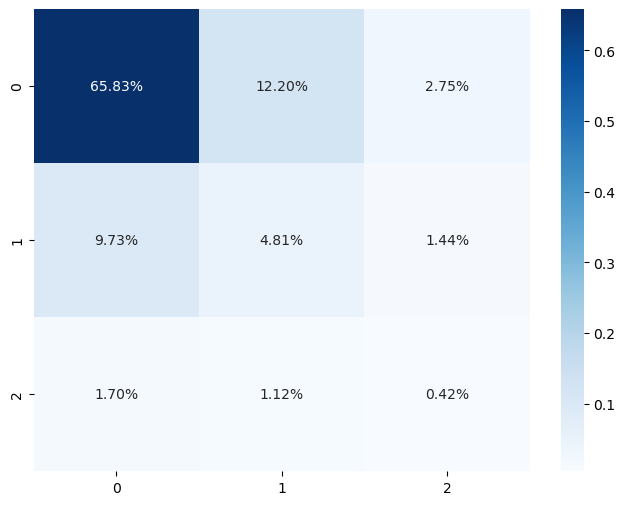

Accuracy: 71.06296240374452
Precision: 0.40300696840225075
Recall: 0.4154622993404729
F1 Score: 0.4075899911755116
Confusion Matrix:
 [[8720 1616  364]
 [1289  637  191]
 [ 225  148   56]]


In [43]:
# Evaluate Model performance
dtree_score = evaluate_model(dtree, X_test, y_test)

print('Accuracy:', dtree_score['acc'])
print('Precision:', dtree_score['prec'])
print('Recall:', dtree_score['rec'])
print('F1 Score:', dtree_score['f1'])
print('Confusion Matrix:\n', dtree_score['cm'])

In [44]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

In [45]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [46]:
print("Trainig Score: ",(rf.score(X_train, y_train))*100,"%")
print("Testing Score: ",(rf.score(X_test, y_test))*100,"%")

Trainig Score:  99.97735037088768 %
Testing Score:  81.06598218330062 %


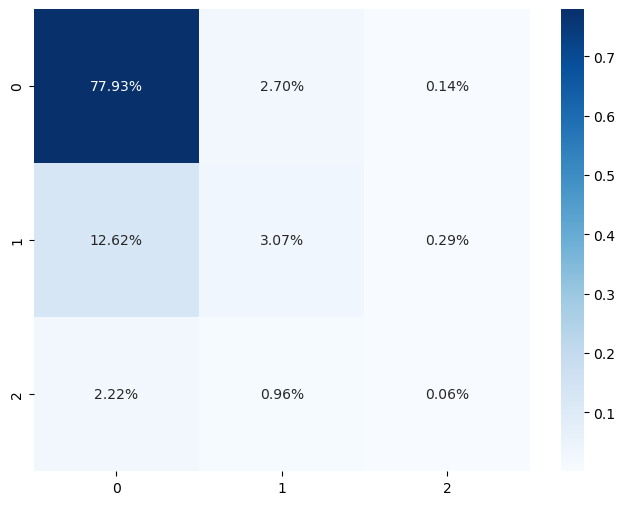

Accuracy: 81.06598218330062
Precision: 0.4731248265478083
Recall: 0.3918891874208206
F1 Score: 0.4003307077468317
Confusion Matrix:
 [[10323   358    19]
 [ 1672   407    38]
 [  294   127     8]]


In [47]:
# Evaluate Model performance
rf_score = evaluate_model(rf, X_test, y_test)

print('Accuracy:', rf_score['acc'])
print('Precision:', rf_score['prec'])
print('Recall:', rf_score['rec'])
print('F1 Score:', rf_score['f1'])
print('Confusion Matrix:\n', rf_score['cm'])

In [48]:
X_train

array([[ 0.20307735, -0.06646769,  0.90685779, ...,  0.98257938,
        -1.2336223 ,  2.01297403],
       [ 0.20307735, -0.23386441,  0.20663733, ...,  0.98257938,
         0.81062088, -0.4967774 ],
       [-0.09570746,  0.51942082,  0.62391468, ...,  0.98257938,
         0.81062088, -0.4967774 ],
       ...,
       [-0.99206191,  0.3520241 , -2.93782189, ..., -1.01772948,
         0.81062088, -0.4967774 ],
       [ 0.30267229, -0.40126113,  0.20663733, ..., -1.01772948,
        -1.2336223 , -0.4967774 ],
       [-1.09165685,  1.27270605, -0.21482938, ...,  0.98257938,
         0.81062088, -0.4967774 ]])

In [49]:
from sklearn.svm import SVC, LinearSVC
svc = LinearSVC()
svc.fit(X_train, y_train)

LinearSVC()

In [50]:
y_pred = svc.predict(X_test)

In [51]:
print("Trainig Score: ",(svc.score(X_train, y_train))*100,"%")
print("Testing Score: ",(svc.score(X_test, y_test))*100,"%")

Trainig Score:  80.79688945093524 %
Testing Score:  81.34531179223916 %


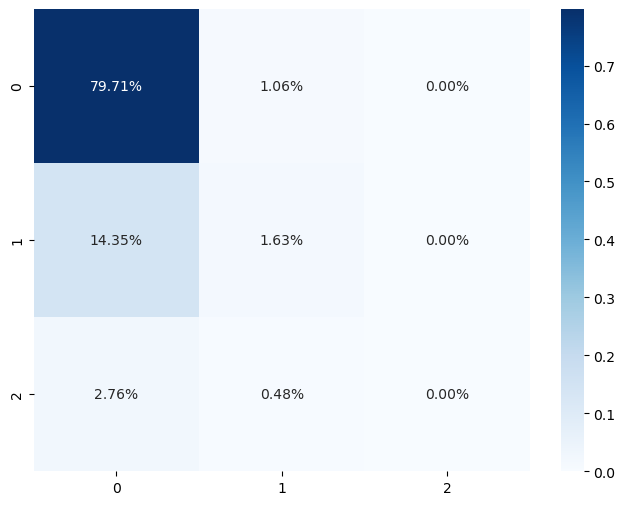

Accuracy: 81.34531179223916
Precision: 0.4458451211452927
Recall: 0.36295120203308917
F1 Score: 0.3559750055493692
Confusion Matrix:
 [[10559   141     0]
 [ 1901   216     0]
 [  366    63     0]]


In [52]:
# Evaluate Model performance
svc_score = evaluate_model(svc, X_test, y_test)

print('Accuracy:', svc_score['acc'])
print('Precision:', svc_score['prec'])
print('Recall:', svc_score['rec'])
print('F1 Score:', svc_score['f1'])
print('Confusion Matrix:\n', svc_score['cm'])

In [53]:
from sklearn.neighbors import KNeighborsClassifier
knc = KNeighborsClassifier(n_neighbors=5)
knc.fit(X_train, y_train)

KNeighborsClassifier()

In [54]:
y_pred = knc.predict(X_test)

In [55]:
print("Trainig Score: ",(knc.score(X_train, y_train))*100,"%")
print("Testing Score: ",(knc.score(X_test, y_test))*100,"%")

Trainig Score:  83.45444593344784 %
Testing Score:  79.5258946096935 %


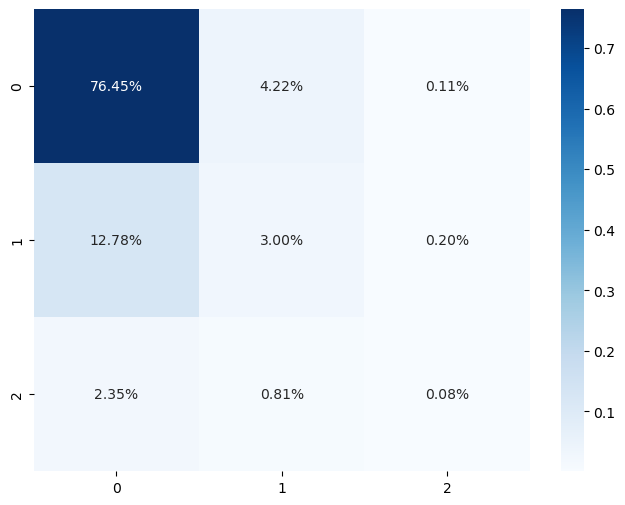

Accuracy: 79.5258946096935
Precision: 0.47193608494754696
Recall: 0.38650856291257313
F1 Score: 0.39413569790827463
Confusion Matrix:
 [[10126   559    15]
 [ 1693   397    27]
 [  311   107    11]]


In [56]:
# Evaluate Model performance
knc_score = evaluate_model(knc, X_test, y_test)

print('Accuracy:', knc_score['acc'])
print('Precision:', knc_score['prec'])
print('Recall:', knc_score['rec'])
print('F1 Score:', knc_score['f1'])
print('Confusion Matrix:\n', knc_score['cm'])

In [57]:
from sklearn.model_selection import cross_val_score

print("\nLogistic Regression:")
print("Training cross validation score: ",round(((cross_val_score(log_reg, X_train, y_train)).mean())*100,2))
print("Testing cross validation score: ",round(((cross_val_score(log_reg, X_test, y_test)).mean())*100,2))

print("\nDecision Tree Classifier: ")
print("Training cross validation score: ",round(((cross_val_score(dtree, X_train, y_train)).mean())*100,2))
print("Testing cross validation score: ",round(((cross_val_score(dtree, X_test, y_test)).mean())*100,2))

print("\nRandom Forest Classifier: ")
print("Training cross validation score: ",round(((cross_val_score(rf, X_train, y_train)).mean())*100,2))
print("Testing cross validation score: ",round(((cross_val_score(rf, X_test, y_test)).mean())*100,2))

print("\nSupport Vector Classifier: ")
print("Training cross validation score: ",round(((cross_val_score(svc, X_train, y_train)).mean())*100,2))
print("Testing cross validation score: ",round(((cross_val_score(svc, X_test, y_test)).mean())*100,2))

print("\nK Nearest Neighbor Classifier: ")
print("Training cross validation score: ",round(((cross_val_score(knc, X_train, y_train)).mean())*100,2))
print("Testing cross validation score: ",round(((cross_val_score(knc, X_test, y_test)).mean())*100,2))


Logistic Regression:
Training cross validation score:  80.68
Testing cross validation score:  81.43

Decision Tree Classifier: 
Training cross validation score:  71.21
Testing cross validation score:  72.04

Random Forest Classifier: 
Training cross validation score:  80.38
Testing cross validation score:  80.97

Support Vector Classifier: 
Training cross validation score:  80.81
Testing cross validation score:  81.38

K Nearest Neighbor Classifier: 
Training cross validation score:  79.2
Testing cross validation score:  79.62
